# Laboratory 2 -- ODE models everywhere: population dynamics and physics

### Solving ODEs in Python -- part 2: numerical solutions

To solve ODEs numerically in Python we need the function ```odeint``` from the library ```scipy```.

In [1]:
# !pip install scipy

In [1]:
from scipy.integrate import odeint

Let us solve the equation
$$
x'=-2x.
$$
describing radioactive decay. Clearly, for a numerical solution we need to have an IVP, as solvers operate on numbers, not symbols. Thus, take, for example, $x(0)=5$. 

For the function ```odeint``` 3 parmeters are required:
- func -- a Python function which defines the right-hand side of the equation,
- y0 -- the value of the initial condition, always at $t_0=0$, i.e., $x(0)=y_0$,
- t -- an array of time points for which to solve the equation.

Let us take a closer look at the structure of the parameter func:

In [5]:
def radioactive_decay(x, t):
    # the first argument is the function in the equation, the second argument is the independent variable the argument of the function
    dxdt = -2 * x  # an auxiliary variable equal to the right-hand side of the equation

    return dxdt

Note that although we do not use the variable t in the body of the function, it must be passed as an argument -- in this way we specify the independent variable. We are ready to solve the equation.

In [6]:
sol = odeint(radioactive_decay, 5, [0.0, 0.5, 1])

In [7]:
sol

array([[5.        ],
       [1.83939729],
       [0.67667641]])

Observe that ```odeint``` returns an array of arrays. It follows from the fact that we can pass more than one initial condition in one call of ```odeint```.

In [8]:
sol2 = odeint(radioactive_decay, [5, 4], [0.0, 0.5, 1])

In [9]:
sol2

array([[5.        , 4.        ],
       [1.83939729, 1.47151783],
       [0.67667641, 0.54134113]])

The shape of this array is (number of time points)$\times$(number of initial conditions) and the $i$-th position of this array contains the values of the solution for all initial conditions at the $i$-th time point. For example, sol2[0] should give us the initial conditions:

In [10]:
sol2[0]

array([5., 4.])

If we want to know the value of the solution with the initial condition $x(0)=4$ at $t=1$, we need to call

In [11]:
sol2[2][1]  # 1 is the third argument in the array of times, 4 is the second IC in the array of ICs

np.float64(0.5413411272249502)

If an equation contains some parameters (and it almost always does), we can pass them to the argument func and specify them when calling ```odeint``` using an addition argument ```args```.

In [12]:
def radioactive_decay_param(x, t, a):
    dxdt = -a * x
    return dxdt


sol3 = odeint(radioactive_decay_param, 5, [0, 0.5, 1],
              args=(2,))  # when there is only one parameter, a comma is required at the end!

In [13]:
sol3

array([[5.        ],
       [1.83939729],
       [0.67667641]])

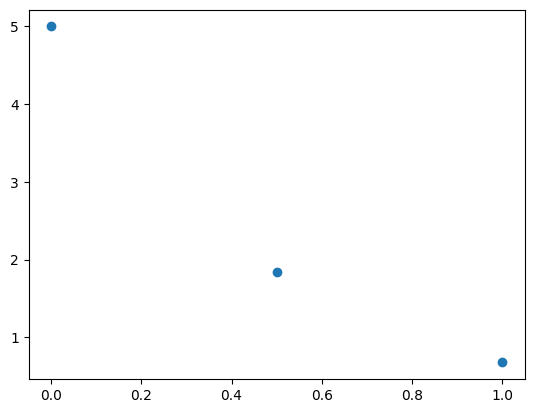

In [14]:
import matplotlib.pyplot as plt

plt.scatter([0, 0.5, 1], sol3)
plt.show()

If there are more than one parameter, then the order of the values of the parameters in ```args``` must coincide with the order of the arguments passed to ```func```.

Cleary, the times we solve the solution at not need to be given explicitly -- we can do it via functions ```arrange``` or ```linspace``` from ```numpy```.

#### Task 1
Let us consider the Verhulst equation
$$
x'=rx\left(1-\frac{x}{K}\right).
$$
- Let $r=2$, $K=5$. Plot in one figure the solutions to this equation with the initial conditions $x(0)=5, x(0)=3, x(0)=7$ at $t=0, 0.1, 0.2,\ldots, 1$.
- Do the same for $r=-3, K=7, x(0)=7, x(0)=4, x(0)=9$.

In [22]:
import numpy as np

In [47]:
def verhulst_equation(x, t, r, K):
    return r * x * (1 - x / K)


def verhulst_jac(x, t, r, K):
    return r - 2 * r * x / K

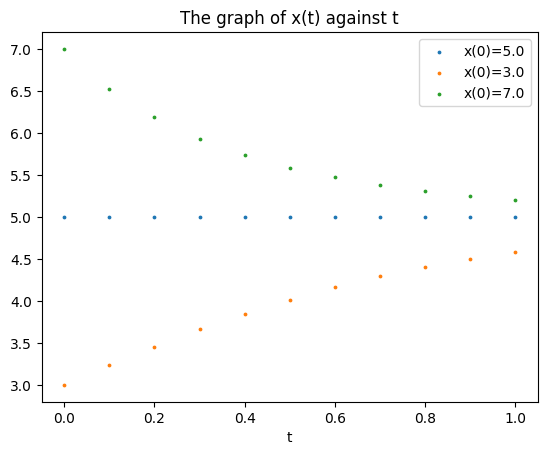

In [49]:
# Declare variables
r = 2
K = 5
time = np.arange(0, 1.1, 0.1)

sol4 = odeint(verhulst_equation, [5, 3, 7], time, args=(r, K), Dfun=verhulst_jac)

for i in range(3):
    plt.scatter(time, sol4[:, i], s=3, label=f'x(0)={sol4[0][i]}')

plt.legend()
plt.title('The graph of x(t) against t')
plt.xlabel('t')
plt.show()

C:\Users\mateu\AppData\Local\Temp\ipykernel_21316\3064233083.py:11: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(verhulst_equation, [x0], time, args=(r, K), Dfun=verhulst_jac, rtol=1e-8, atol=1e-10)


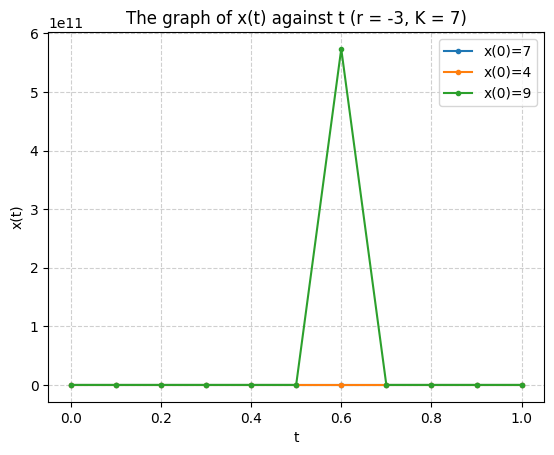

In [48]:
# Declare variables
r = -3
K = 7
time = np.arange(0, 1.1, 0.1)

initial_conditions = [7, 4, 9]

# Rozwiązujemy każde równanie osobno w pętli
for x0 in initial_conditions:
    # Zwróć uwagę: podajemy [x0] jako listę jednoelementową
    sol = odeint(verhulst_equation, [x0], time, args=(r, K), Dfun=verhulst_jac, rtol=1e-8, atol=1e-10)

    # sol to tablica 2D, wyciągamy pierwszą kolumnę (indeks 0) do wykresu
    plt.plot(time, sol[:, 0], marker='o', markersize=3, label=f'x(0)={x0}')

plt.legend()
plt.title('The graph of x(t) against t (r = -3, K = 7)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Task 2
Compare the solution to the Verhulst equation obtained through ```odeint``` with the one obtained through ```dsolve``` from ```sympy``` and ```lambdify```. Plot the graphs in a single picture.

In [29]:
# sympy version
from sympy import symbols, Function, Eq, dsolve, lambdify

t = symbols('t')
x = Function('x')


def verhulst(K, initial):
    eq_ver = Eq(x(t).diff(t), x(t) * (1 - x(t) / K))  # Here r = 1, so there is no other multiplication with x(t)
    sol_ver = dsolve(eq_ver, x(t), ics={x(0): initial})
    return lambdify(t, sol_ver.rhs)

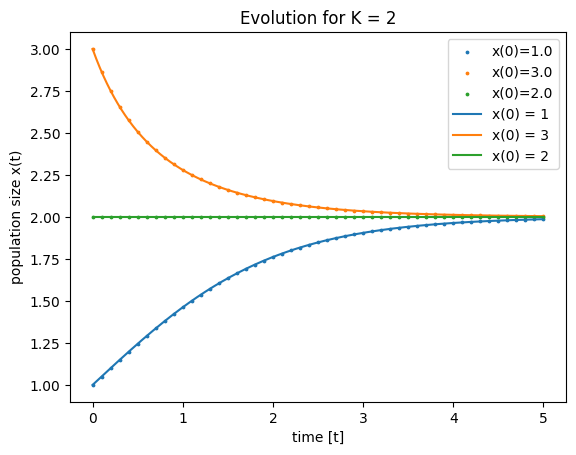

In [36]:
# Generate the plots for Verhulst function

# Sympy version
times = np.arange(0, 5, 0.01)

K1 = 2
x0_case1 = [1, 3, 2]

functions_1 = [verhulst(K1, x0) for x0 in x0_case1]

# odeint version
r = 1
K = 2
time = np.arange(0, 5.1, 0.1)

sol4 = odeint(verhulst_equation, [1, 3, 2], time, args=(r, K), Dfun=verhulst_jac)

for i in range(3):
    plt.scatter(time, sol4[:, i], s=3, label=f'x(0)={sol4[0][i]}')

# Plot for K = 2
for i in range(3):
    plt.plot(times, [functions_1[i](t) for t in times], label=f'x(0) = {x0_case1[i]}')

plt.title('Evolution for K = 2')
plt.xlabel('time [t]')
plt.ylabel('population size x(t)')
plt.legend()
plt.show()

Let us now take a look at how to solve systems of ODEs. Consider the following simple system:
$$
\left\{\begin{array}{ll}
x'=-y\\
y'=x
\end{array}\right..
$$
Similarly as in the scalar case, we need to write a Python function that will be later passed to ```odeint```. Although we have a system of equation, only one variable denoting the unknown functions in the system is passed to the Python function. Then, in the body of this Python function, we specify that our unknown function is in fact a vector of functions.

In [37]:
import numpy as np


def ODEsys(x, t):
    x, y = x  # here we specify that we have a vector of functions
    dxdt = [-y, x]  # right-hand side of our ODE
    return dxdt


times = np.arange(0, 10, 0.1)

ODEsys_sol = odeint(ODEsys, [3, 5], times)
ODEsys_sol

array([[ 3.        ,  5.        ],
       [ 2.48584547,  5.27452105],
       [ 1.94685314,  5.49634085],
       [ 1.3884085 ,  5.66324304],
       [ 0.81609133,  5.77355996],
       [ 0.23562007,  5.8261894 ],
       [-0.34720544,  5.82060549],
       [-0.92656178,  5.756864  ],
       [-1.49666023,  5.63560183],
       [-2.05180455,  5.45803059],
       [-2.58644791,  5.22592452],
       [-3.09524834,  4.94160273],
       [-3.57312207,  4.60790609],
       [-4.01529434,  4.22816877],
       [-4.4173471 ,  3.80618501],
       [-4.77526324,  3.34617108],
       [-5.08546651,  2.85272332],
       [-5.34485749,  2.33077208],
       [-5.55084442,  1.78553255],
       [-5.70136914,  1.22245256],
       [-5.79492766,  0.64715823],
       [-5.83058518,  0.06539771],
       [-5.80798542, -0.51701625],
       [-5.7273542 , -1.09426435],
       [-5.58949713, -1.66057892],
       [-5.39579166, -2.21030154],
       [-5.14817322, -2.73793955],
       [-4.84911594, -3.23822098],
       [-4.5016079 ,

In this case ```odeint``` returns a vector of pairs of the form $[x(t), y(t)]$.

__Note__: Contrary to the case of a scalar equation, here we cannot give more than one initial condition in ```odeint```.

A solution to a system of two equations can be plotted in two ways. The first one, probably more obvious, is to plot each function in the standard coordinates, i.e., values against arguments.

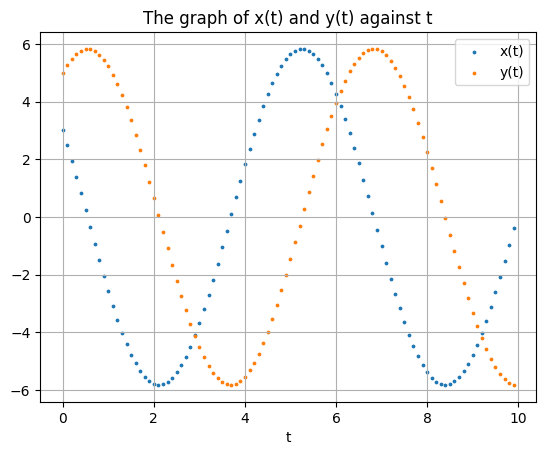

In [38]:
plt.scatter(times, ODEsys_sol[:, 0], s=3, label='x(t)')
plt.scatter(times, ODEsys_sol[:, 1], s=3, label='y(t)')
plt.grid()
plt.legend()
plt.title('The graph of x(t) and y(t) against t')
plt.xlabel('t')
plt.show()

Another way is to plot pairs of the form $[x(t), y(t)]$, i.e., for a given $t$, we choose the value $x(t)$ on the $x$-axis and the value $y(t)$ on the $y$-axis. Although in this way we do not know the values of $t$ the points correspond to, we can see how the functions depend on each other.

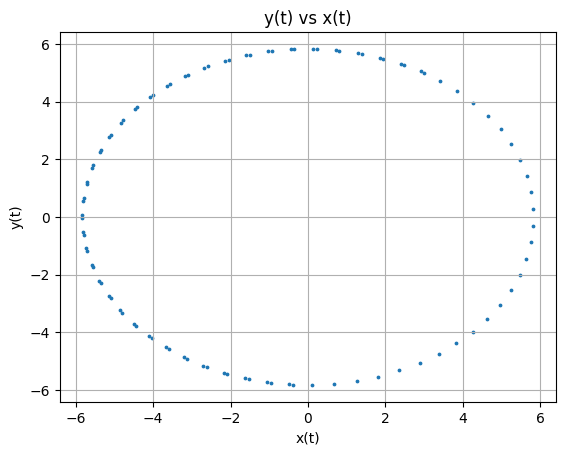

In [39]:
plt.scatter(ODEsys_sol[:, 0], ODEsys_sol[:, 1], s=3)
plt.grid()
plt.title('y(t) vs x(t)')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.show()

From this graph we can see, for example, that while x is increasing from 0 to 6, $y$ is increasing from -6 to 0, then, $x$ is decreasing back to 0 while $y$ is still increasing from 0 to 6 etc. However, we do not know, for example, how much time does it take for $x$ to increase from 0 to 6 -- this information is 'hidden' along the dotted line.

### Verhulst model with the Allee effect

Let us modify the Verhulst equation by introducing an additional factor:
$$
x'=rx(x-A)\left(1-\frac{x}{K}\right).
$$
Here, $A$ is the critical size of the population needed for its survival. We assume that $0<A<K$. 

#### Task 3
For simplicity, assume $r=1$.
- Let $A=2, K=5$. Plot in a single figure the solutions with initial conditions $x(0)=0, x(0)=1, x(0)=2, x(0)=3, x(0)=5, x(0)=7$.
- Do the same for $A=5, K=12, x(0)=0, x(0)=1, x(0)=4, x(0)=5, x(0)=8, x(0)=11, x(0)=12, x(0)=14, x(0)=17$.
- Explain how the behaviour of the solutions is related to the values of $A$ and $K$.

The pheonomenon observed in this model is called the _Allee effect_.

In [40]:
def verhulst_allee(x, t, r, A, K):
    return r * x * (x - A) * (1 - x / K)

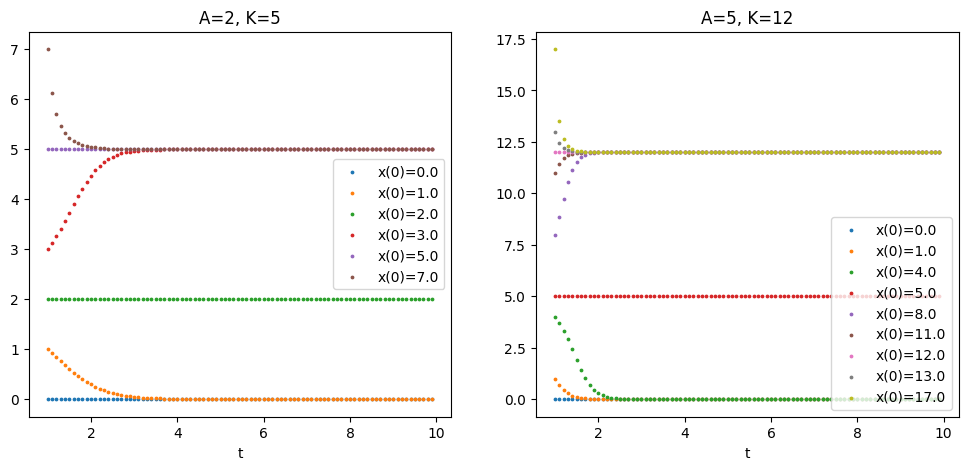

In [41]:
time = np.arange(1, 10, 0.1)

sol6 = odeint(verhulst_allee, [0, 1, 2, 3, 5, 7], time, args=(1, 2, 5))  # A=2, K=5
sol7 = odeint(verhulst_allee, [0, 1, 4, 5, 8, 11, 12, 13, 17], time, args=(1, 5, 12))  # A=5, K=12

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for i in range(6):
    plt.scatter(time, sol6[:, i], s=3, label=f'x(0)={sol6[0][i]}')

plt.legend()
plt.title('A=2, K=5')
plt.xlabel('t')

plt.subplot(1, 2, 2)

for i in range(9):
    plt.scatter(time, sol7[:, i], s=3, label=f'x(0)={sol7[0][i]}')

plt.legend()
plt.title('A=5, K=12')
plt.xlabel('t')

plt.show()

We can observe that if the initial condition is less than $A$, the solution tends to 0 (extinction), while if it is greater than $A$, the solution tends to $K$ (carrying capacity). The point $A$ is an unstable equilibrium, while $0$ and $K$ are stable equilibria. The Allee effect describes the phenomenon when a population below a certain critical size cannot survive due to various reasons (e.g., difficulty in finding mates, cooperative defense etc.).

### Pendulum equation

Let us consider the equation describing the displacement of a pendulum from the vertical:
$$
\theta''+\frac{g}{l}\sin\theta=0,
$$
where $\theta$ is the angle between the pendulum and the vertical, $g$ is the gravitational force and $l$ is the length of the rod. It is an idealized model valid under some additional assumptions; in particular, we assume no friction (i.e., the pendulum does not lose kinetic energy).

#### Task 4
Let $g=l=1$. 
- Convert this equation into a system of equations for the vector $[x,y]$.
- Explain the physical interpretation of $x$ and $y$. 
- Plot the solution with the initial condition $[1,1]$. 
    - What happens with $y$ when $x=0$ and vice versa? Explain this from the physical point of view.
- Plot the solution with the initial condition $[1,-1]$.
    - Observe that here $x$ decreases immediately, while in the previous case it increases at the beginning. Explain this phenomenon from the physical point of view.
- Plot the solutions with the initial conditions $[\pi, 0]$ and $[\pi, 1]$. Explain the behaviour.
- Plot all the above solutions in coordinates $(x(t), y(t))$ in a single figure. Explain what you can see.

In [54]:
def pendulum(state, t):
    x, y = state
    dxdt = y
    dydt = -np.sin(x)
    return [dxdt, dydt]

The system is:
$$
\begin{cases}
x' = y \\
y' = -\sin x
\end{cases}
$$

Where $x = \theta$ (angle), $y = \theta'$ (angular velocity).


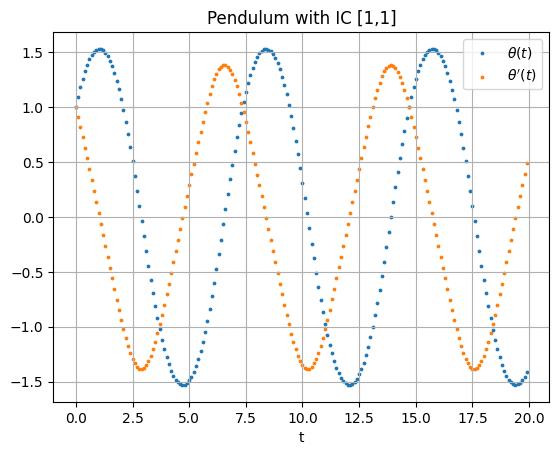

In [55]:
time = np.arange(0, 20, 0.1)

# Initial condition [1,1]
sol1 = odeint(pendulum, [1, 1], time)

plt.scatter(time, sol1[:, 0], s=3, label=r'$\theta(t)$')
plt.scatter(time, sol1[:, 1], s=3, label=r"$\theta'(t)$")
plt.legend()
plt.title('Pendulum with IC [1,1]')
plt.xlabel('t')
plt.grid()
plt.show()


When $x=0$ (vertical position), $y$ reaches its maximum (highest speed). When $y=0$ (stop), $x$ is at maximum displacement.

<b>Physically:</b> At bottom ($θ=0$), velocity is max; at top ($θ=π$), velocity is 0.


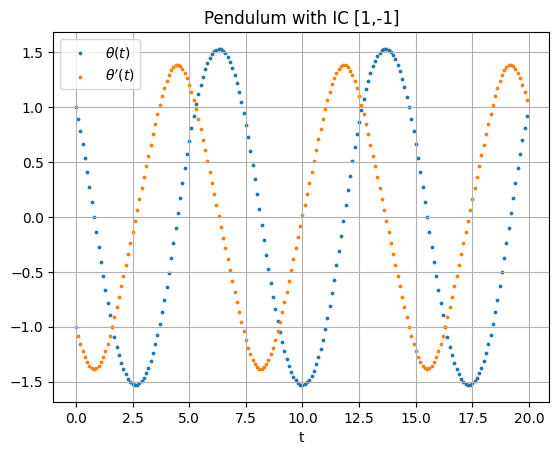

In [56]:
# Initial condition [1,-1]
sol2 = odeint(pendulum, [1, -1], time)

plt.scatter(time, sol2[:, 0], s=3, label=r'$\theta(t)$')
plt.scatter(time, sol2[:, 1], s=3, label=r"$\theta'(t)$")
plt.legend()
plt.title('Pendulum with IC [1,-1]')
plt.xlabel('t')
plt.grid()
plt.show()


Here $x$ decreases immediately because initial velocity is negative (swinging left). In previous case, positive velocity causes initial increase.

<b>Physically:</b> Positive velocity pushes towards increasing angle, negative towards decreasing.


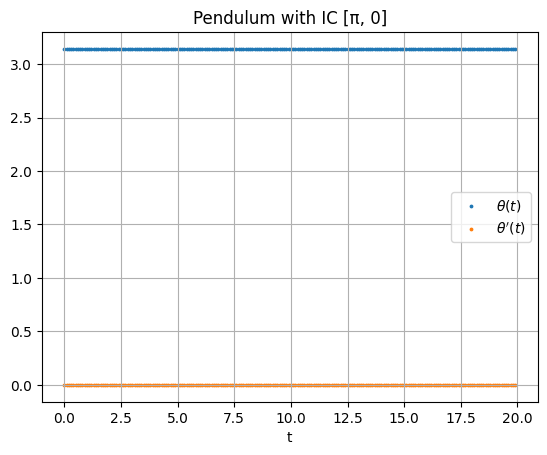

In [57]:
# Initial condition [π, 0]
sol3 = odeint(pendulum, [np.pi, 0], time)

plt.scatter(time, sol3[:, 0], s=3, label=r'$\theta(t)$')
plt.scatter(time, sol3[:, 1], s=3, label=r"$\theta'(t)$")
plt.legend()
plt.title('Pendulum with IC [π, 0]')
plt.xlabel('t')
plt.grid()
plt.show()


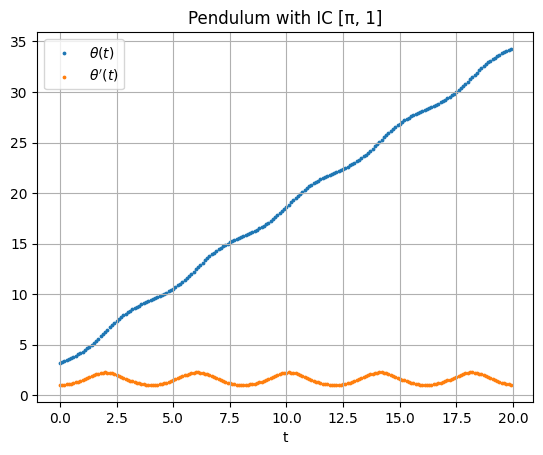

In [58]:

# Initial condition [π, 1]
sol4 = odeint(pendulum, [np.pi, 1], time)

plt.scatter(time, sol4[:, 0], s=3, label=r'$\theta(t)$')
plt.scatter(time, sol4[:, 1], s=3, label=r"$\theta'(t)$")
plt.legend()
plt.title('Pendulum with IC [π, 1]')
plt.xlabel('t')
plt.grid()
plt.show()


For [π, 0]: Starts at unstable equilibrium, stays or oscillates slightly due to numerical error.

For [π, 1]: Small perturbation from unstable point, starts oscillating.


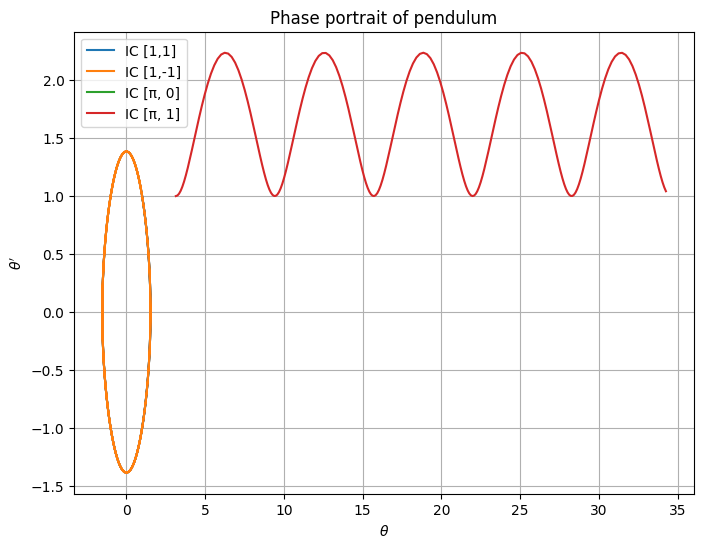

In [61]:

plt.figure(figsize=(8, 6))
plt.plot(sol1[:, 0], sol1[:, 1], label='IC [1,1]')
plt.plot(sol2[:, 0], sol2[:, 1], label='IC [1,-1]')
plt.plot(sol3[:, 0], sol3[:, 1], label='IC [π, 0]')
plt.plot(sol4[:, 0], sol4[:, 1], label='IC [π, 1]')
plt.xlabel(r'$\theta$')
plt.ylabel(r"$\theta'$")
plt.title('Phase portrait of pendulum')
plt.legend()
plt.grid()
plt.show()


The phase portrait shows closed orbits (periodic motion) for most ICs. The [π,0] stays at equilibrium (unstable), others oscillate around θ=0.
